# Melbourne Housing Price Prediction — Regression

## 1. Dataset Audit

This notebook develops regression models to predict property prices using the Melbourne Housing dataset.

The first stage is to understand the dataset structure, data types, missing values, duplicate records, and potential issues that need to be addressed before modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

Loading the dataset into the .ipynb file.

In [3]:
df = pd.read_csv('C:\\Users\\gamin\\OneDrive\\Desktop\\sem-5\\ML\\ML_Project\\ML-Capstone-Project\\data\\regression\\Melbourne_housing.csv')
df.head()

C:\Users\gamin\AppData\Local\Temp\ipykernel_19840\2597918905.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:\\Users\\gamin\\OneDrive\\Desktop\\sem-5\\ML\\ML_Project\\ML-Capstone-Project\\data\\regression\\Melbourne_housing.csv')


,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longtitude,Regionname,Propertycount,ParkingArea,Price
0,Abbotsford,68 Studley St,2,h,SS,Jellis,3/9/2016,2.5,3067.0,2.0,...,126.0,inf,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,Carport,NaN
1,Airport West,154 Halsey Rd,3,t,PI,Nelson,3/9/2016,13.5,3042.0,3.0,...,303.0,225,2016.0,Moonee Valley City Council,-37.7180,144.8780,Western Metropolitan,3464.0,Detached Garage,840000.0
2,Albert Park,105 Kerferd Rd,2,h,S,hockingstuart,3/9/2016,3.3,3206.0,2.0,...,120.0,82,1900.0,Port Phillip City Council,-37.8459,144.9555,Southern Metropolitan,3280.0,Attached Garage,1275000.0
3,Albert Park,85 Richardson St,2,h,S,Thomson,3/9/2016,3.3,3206.0,2.0,...,159.0,inf,NaN,Port Phillip City Council,-37.8450,144.9538,Southern Metropolitan,3280.0,Indoor,1455000.0
4,Alphington,30 Austin St,3,h,SN,McGrath,3/9/2016,6.4,3078.0,3.0,...,174.0,122,2003.0,Darebin City Council,-37.7818,145.0198,Northern Metropolitan,2211.0,Parkade,NaN


## Dimensions of the Dataset



In [4]:
df.shape

(34857, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Method         34857 non-null  object 
 5   SellerG        34857 non-null  object 
 6   Date           34857 non-null  object 
 7   Distance       34856 non-null  float64
 8   Postcode       34856 non-null  float64
 9   Bedroom        26640 non-null  float64
 10  Bathroom       26631 non-null  float64
 11  Car            26129 non-null  float64
 12  Landsize       23047 non-null  float64
 13  BuildingArea   13760 non-null  object 
 14  YearBuilt      15551 non-null  float64
 15  CouncilArea    34854 non-null  object 
 16  Latitude       26881 non-null  float64
 17  Longtitude     26881 non-null  float64
 18  Region

## Descriptive Statistics of the dataset

These provide the information about the numerical attributes as well as categorical attributes in the dataset.

In [6]:
df.describe()

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,YearBuilt,Latitude,Longtitude,Propertycount,Price
count,34857.000000,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,15551.000000,26881.000000,26881.000000,34854.000000,2.724700e+04
mean,3.031012,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,1965.289885,-37.810634,145.001851,7572.888306,1.050173e+06
std,0.969933,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,37.328178,0.090279,0.120169,4428.090313,6.414671e+05
min,1.000000,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.190430,144.423790,83.000000,8.500000e+04
25%,2.000000,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,1940.000000,-37.862950,144.933500,4385.000000,6.350000e+05
50%,3.000000,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,1970.000000,-37.807600,145.007800,6763.000000,8.700000e+05
75%,4.000000,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,2000.000000,-37.754100,145.071900,10412.000000,1.295000e+06
max,16.000000,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,2106.000000,-37.390200,145.526350,21650.000000,1.120000e+07


In [7]:
df.describe(include = 'object')

,Suburb,Address,Type,Method,SellerG,Date,BuildingArea,CouncilArea,Regionname,ParkingArea
count,34857,34857,34857,34857,34857,34857,13760,34854,34857,34857
unique,351,34009,3,9,388,78,994,33,8,8
top,Reservoir,5 Charles St,h,S,Jellis,28/10/2017,120,Boroondara City Council,Southern Metropolitan,Carport
freq,844,6,23980,19744,3359,1119,177,3675,11836,6243


### Missing Value Analysis

The dataset is checked for missing values in each feature. Both the number and percentage of missing observations are calculated to understand the extent of missing data and determine appropriate preprocessing strategies later.

In [ ]:

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending = False)

print("Missing values in the dataset:\n", missing_values)

Missing values in the dataset:
 BuildingArea     21097
YearBuilt        19306
Landsize         11810
Car               8728
Bathroom          8226
Bedroom           8217
Latitude          7976
Longtitude        7976
Price             7610
CouncilArea          3
Propertycount        3
Distance             1
Postcode             1
dtype: int64


### Missing Value Percentage

The percentage of missing observations is calculated to assess the severity of missing data across different features.

In [13]:
missing_value_percentage = (df.isnull().sum() / len(df)) * 100

missing_value_percentage = missing_value_percentage[missing_value_percentage > 0].sort_values(ascending = False)
print("Percentage of missing values in the dataset:\n", missing_value_percentage)

Percentage of missing values in the dataset:
 BuildingArea     60.524428
YearBuilt        55.386293
Landsize         33.881286
Car              25.039447
Bathroom         23.599277
Bedroom          23.573457
Latitude         22.882061
Longtitude       22.882061
Price            21.832057
CouncilArea       0.008607
Propertycount     0.008607
Distance          0.002869
Postcode          0.002869
dtype: float64


### Missing Value Visualization

A bar chart is used to visualize the percentage of missing observations for features containing missing values.

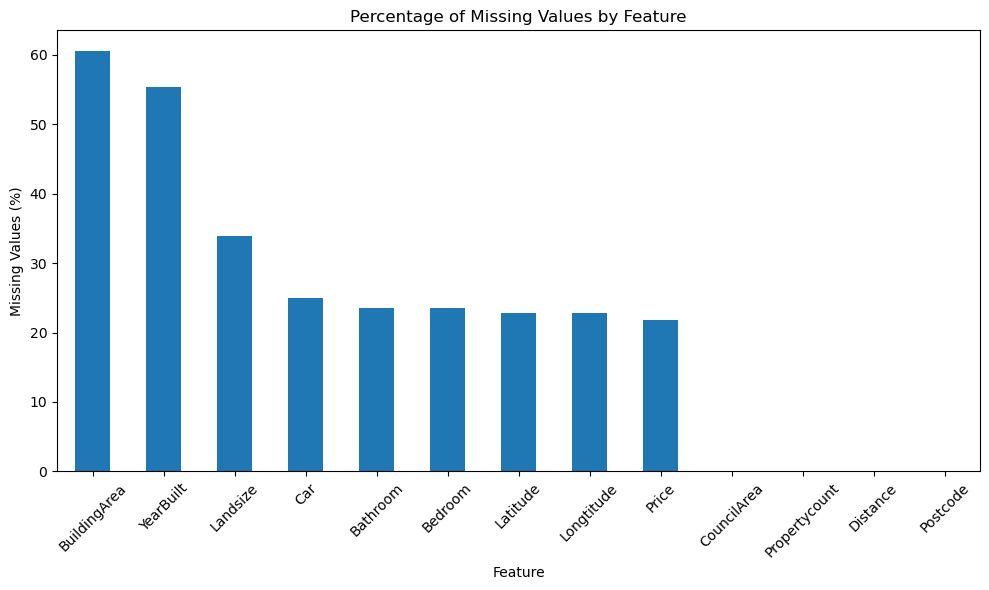

In [15]:
plt.figure(figsize=(10, 6))

missing_value_percentage.plot(kind="bar")

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Duplicate Record Analysis

The dataset is checked for completely duplicated rows to identify repeated observations.

In [16]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


### Data Type Analysis

The data types of all variables are inspected to identify numerical, categorical, date, and potentially malformed columns that require preprocessing.

In [17]:
df.dtypes

Suburb            object
Address           object
Rooms              int64
Type              object
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom          float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea      object
YearBuilt        float64
CouncilArea       object
Latitude         float64
Longtitude       float64
Regionname        object
Propertycount    float64
ParkingArea       object
Price            float64
dtype: object

### Cardinality Analysis

The number of unique values in each feature is examined to understand the cardinality of categorical variables and identify high-cardinality features that may require special treatment.

In [19]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Suburb: 351
Address: 34009
Rooms: 12
Type: 3
Method: 9
SellerG: 388
Date: 78
Distance: 215
Postcode: 211
Bedroom: 15
Bathroom: 11
Car: 15
Landsize: 1684
BuildingArea: 994
YearBuilt: 160
CouncilArea: 33
Latitude: 13402
Longtitude: 14524
Regionname: 8
Propertycount: 342
ParkingArea: 8
Price: 2871


### Investigation of BuildingArea

The BuildingArea feature is stored as an object rather than a numerical data type. Its values are inspected to determine the reason for the mixed data type and identify an appropriate cleaning strategy.

In [20]:
print("Data type:", df["BuildingArea"].dtype)

print("\nSample values:")
print(df["BuildingArea"].dropna().head(20))

Data type: object

Sample values:
0         inf
1         225
2          82
3         inf
4         122
5         263
6         inf
7         242
8         108
9         251
10        117
11    missing
12    missing
13         76
14        135
15    missing
16        399
17        inf
18        inf
19        inf
Name: BuildingArea, dtype: object


In [21]:
print("\nPython data types found:")
print(df["BuildingArea"].dropna().map(type).value_counts())


Python data types found:
BuildingArea
<class 'str'>      12930
<class 'float'>      830
Name: count, dtype: int64


In [22]:
print("\nSample unique values:")
print(df["BuildingArea"].dropna().unique()[:30])


Sample unique values:
['inf' '225' '82' '122' '263' '242' '108' '251' '117' 'missing' '76' '135'
 '399' '118' '103' '180' '123' '218' '129' '167' '154' '275' '121' '146'
 '125' '255' '94' '75' '254' '156']


### Target Variable Analysis

Price is the target variable for the regression task. Its data type, missing values, and descriptive statistics are examined before preprocessing.

In [8]:
print("Target variable: Price")
print("Data type:", df["Price"].dtype)
print("Missing values:", df["Price"].isnull().sum())

print("\nDescriptive statistics:")
print(df["Price"].describe())

Target variable: Price
Data type: float64
Missing values: 7610

Descriptive statistics:
count    2.724700e+04
mean     1.050173e+06
std      6.414671e+05
min      8.500000e+04
25%      6.350000e+05
50%      8.700000e+05
75%      1.295000e+06
max      1.120000e+07
Name: Price, dtype: float64
